# Part 5 — Model Comparison & Strategies

In this section, we evaluate the performance of our trained reinforcement learning agents:
- Policy Gradient (PG)
- Deep Q-Network (DQN)

We compare them against:
- A random baseline agent
- A strong rule-based agent
- A pretrained CNN (Josh's model)

We measure win rate, draw rate, and loss rate across multiple games to understand
relative performance and generalization.

## Setup: Load Models and Agents

We load all trained models and wrap them in a common `ModelAgent` interface.

Agents used:
- PG agent (policy-based RL)
- DQN agent (value-based RL)
- StrongRuleAgent (heuristic baseline)
- RandomAgent (sanity check baseline)
- Josh's CNN agent (supervised learning baseline)

In [2]:
# ── Setup & Load Models ──────────────────────────────────────────────────────
import os, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Upload your files first
from google.colab import files
uploaded = files.upload()
# Upload: connect4_env.py, loader.py, josh_cnn.h5,
#         m1_pg_final.keras, dqn_best_cont.keras

# Copy required files into models/ directory for import compatibility
os.makedirs("models", exist_ok=True)
for fname, dest in [
    ("loader.py",   "models/loader.py"),
    ("josh_cnn.h5", "models/josh_cnn.h5"),
]:
    if os.path.exists(fname):
        shutil.copy(fname, dest)
with open("models/__init__.py", "w") as f:
    f.write("")

from connect4_env import (
    encode_board, legal_moves, game_over, make_board, step,
    ModelAgent, RandomAgent, StrongRuleAgent, evaluate_agents,
    find_winning_move
)
from models.loader import load_model

# Load your two trained models
pg_model  = keras.models.load_model("m1_pg_final.keras",  compile=False)
dqn_model = keras.models.load_model("dqn_best_cont.keras", compile=False)

# Wrap models as agents with greedy (deterministic) play + rule-based safety
pg_agent  = ModelAgent(pg_model,  sample=False, strong=True)
dqn_agent = ModelAgent(dqn_model, sample=False, strong=True)

strong_agent = StrongRuleAgent()
random_agent = RandomAgent()
josh_agent   = ModelAgent(load_model("josh_cnn"), sample=False, strong=True)

print("All models loaded OK")

Saving connect4_env.py to connect4_env.py
Saving loader.py to loader.py
Saving josh_cnn.h5 to josh_cnn.h5
Saving dqn_best_cont.keras to dqn_best_cont.keras
Saving m1_pg_final.keras to m1_pg_final.keras
All models loaded OK


## Head-to-Head Evaluation

We evaluate each agent against different opponents over 200 games.

Metrics:
- **Win rate**: percentage of games won
- **Draw rate**: percentage of tied games
- **Loss rate**: remaining games

This helps us understand:
- Whether the model beats random play (sanity check)
- How it performs against stronger heuristics
- How it compares to other learned agents

In [ ]:
# ── Head-to-Head Comparison ──────────────────────────────────────────────────
N = 200  # games per matchup

# Print formatted results for each matchup
results = {
    "PG vs Random":   evaluate_agents(pg_agent,  random_agent,  n_games=N),
    "DQN vs Random":  evaluate_agents(dqn_agent, random_agent,  n_games=N),
    "PG vs Strong":   evaluate_agents(pg_agent,  strong_agent,  n_games=N),
    "DQN vs Strong":  evaluate_agents(dqn_agent, strong_agent,  n_games=N),
    "PG vs Josh":     evaluate_agents(pg_agent,  josh_agent,    n_games=N),
    "DQN vs Josh":    evaluate_agents(dqn_agent, josh_agent,    n_games=N),
    "PG vs DQN":      evaluate_agents(pg_agent,  dqn_agent,     n_games=N),
    "DQN vs PG":      evaluate_agents(dqn_agent, pg_agent,      n_games=N),
}

print(f"\n{'Matchup':<20} {'Win%':>6} {'Draw%':>7} {'Loss%':>7}")
print("-" * 45)
for name, r in results.items():
    win  = r['win_rate']
    draw = r.get('draw_rate', 1 - r['win_rate'] - r.get('loss_rate', 0))
    loss = 1 - win - draw
    print(f"{name:<20} {win:>6.1%} {draw:>7.1%} {loss:>7.1%}")


Matchup                Win%   Draw%   Loss%
---------------------------------------------
PG vs Random         100.0%    0.0%    0.0%
DQN vs Random         99.5%    0.5%    0.0%
PG vs Strong          86.0%   14.0%    0.0%
DQN vs Strong         65.0%   35.0%    0.0%
PG vs Josh            50.0%   50.0%    0.0%
DQN vs Josh           50.0%   50.0%    0.0%
PG vs DQN              0.0%  100.0%    0.0%
DQN vs PG            100.0%    0.0%    0.0%


## Win Rate Comparison (PG vs DQN)

We visualize win rates across different opponents to compare:
- Consistency of each model
- Relative strengths across difficulty levels

The dashed line at 50% represents a neutral baseline.

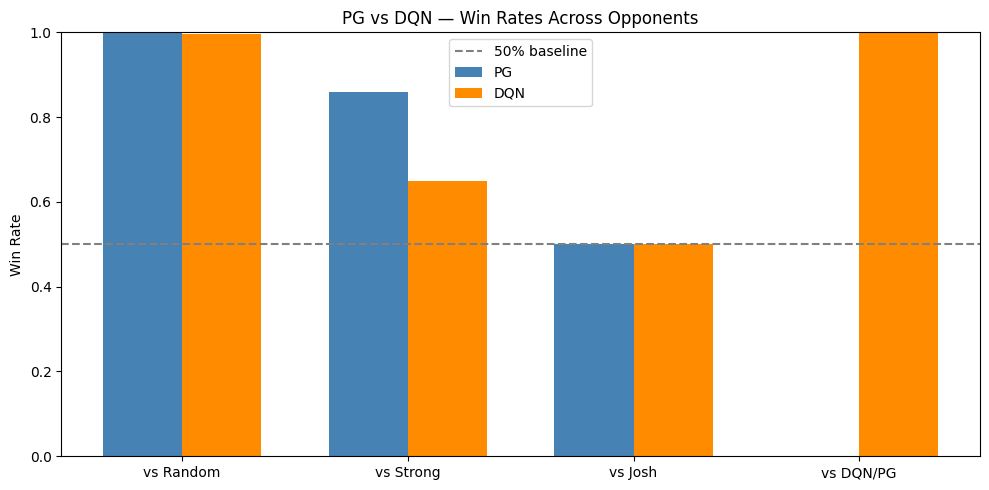

In [ ]:
# ── Comparison Bar Chart ─────────────────────────────────────────────────────
opponents = ["vs Random", "vs Strong", "vs Josh", "vs DQN/PG"]
pg_wins  = [
    results["PG vs Random"]["win_rate"],
    results["PG vs Strong"]["win_rate"],
    results["PG vs Josh"]["win_rate"],
    results["PG vs DQN"]["win_rate"],
]
dqn_wins = [
    results["DQN vs Random"]["win_rate"],
    results["DQN vs Strong"]["win_rate"],
    results["DQN vs Josh"]["win_rate"],
    results["DQN vs PG"]["win_rate"],
]

x   = np.arange(len(opponents))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, pg_wins,  w, label="PG",  color="steelblue")
ax.bar(x + w/2, dqn_wins, w, label="DQN", color="darkorange")
ax.axhline(0.5, color="gray", linestyle="--", label="50% baseline")
ax.set_xticks(x); ax.set_xticklabels(opponents)
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("PG vs DQN — Win Rates Across Opponents")
ax.legend()
plt.tight_layout()
plt.savefig("pg_vs_dqn_comparison.png", dpi=150)
plt.show()

## Minimax Enhancement

We augment our trained models with a shallow Minimax search (depth = 2).

Key idea:
- The neural network evaluates board positions
- Minimax simulates future moves to improve decision quality

We use alpha-beta pruning to reduce computation.

Special handling:
- For Policy Gradient (PG), outputs are probabilities → converted to log-space
  for meaningful comparison during search.

In [6]:
def minimax(board, depth, player, mm_player, model, alpha=-np.inf, beta=np.inf, is_pg=False):

    # Terminal state: assign win/loss/draw values
    done, winner = game_over(board)
    if done:
        if winner == mm_player:  return 1.0
        if winner != 0:          return -1.0
        return 0.0

    # Leaf node: evaluate board using neural network
    if depth == 0:
        enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
        out = model(enc, training=False).numpy()[0]

        legal = legal_moves(board)

        # Mask illegal moves so they are never selected
        mask  = np.full(7, -1e9); mask[legal] = 0.0

        # PG outputs probabilities → convert to log-space for minimax
        if is_pg:
            out = np.log(out + 1e-8)

        return float(np.max(out + mask))

    cols = legal_moves(board)

    # Maximizing player (our agent)
    if player == mm_player:
        best = -np.inf
        for col in cols:
            new_board, _ = step(board, col, player)
            best  = max(best, minimax(new_board, depth-1, -player,
                                      mm_player, model, alpha, beta, is_pg))
            alpha = max(alpha, best)
            if beta <= alpha: break
        return best

    # Minimizing player (opponent)
    else:
        best = np.inf
        for col in cols:
            new_board, _ = step(board, col, player)
            best = min(best, minimax(new_board, depth-1, -player,
                                     mm_player, model, alpha, beta, is_pg))
            beta = min(beta, best)
            if beta <= alpha: break
        return best

### Minimax Move Selection

Before running search, we apply simple tactical rules:
1. Take a winning move if available
2. Block opponent’s winning move

If neither applies, Minimax is used to evaluate possible moves.

In [4]:
def select_move_minimax(board, player, model, depth=2, is_pg=False):
    # Apply simple tactics before running minimax (win or block)
    col = find_winning_move(board, player)
    if col is not None: return col
    col = find_winning_move(board, -player)
    if col is not None: return col

    cols = legal_moves(board)
    best_score, best_col = -np.inf, cols[0]
    for col in cols:
        new_board, _ = step(board, col, player)
        score = minimax(new_board, depth-1, -player, player, model, is_pg=is_pg)
        if score > best_score:
            best_score, best_col = score, col
    return best_col


class MinimaxAgent:
    def __init__(self, model, depth=2, is_pg=False):
        self.model = model
        self.depth = depth
        self.is_pg = is_pg # whether model outputs probabilities (PG)

    def select_move(self, board, player):
        return select_move_minimax(board, player, self.model,
                                   self.depth, self.is_pg)


# create agents
mm_pg_agent  = MinimaxAgent(pg_model,  depth=2, is_pg=True)   # pg flag on
mm_dqn_agent = MinimaxAgent(dqn_model, depth=2, is_pg=False)  # dqn unchanged
print("Minimax agents ready")

Minimax agents ready


## Minimax Evaluation

We compare Minimax-enhanced agents against:
- Random agent
- Strong heuristic agent
- Josh's CNN
- Each other

We also compare against the original (non-Minimax) versions to measure improvement.

In [ ]:
# ── Fix Keras input warning before minimax runs ────────────────────────────
dummy_board = make_board()
dummy_enc   = encode_board(dummy_board, 1)[np.newaxis].astype(np.float32)

# warm up both models so Keras stops complaining
_ = pg_model(dummy_enc,  training=False)
_ = dqn_model(dummy_enc, training=False)
print("Models warmed up -- input structure cached.")

Models warmed up -- input structure cached.


In [ ]:
# ── Evaluate Minimax ─────────────────────────────────────────────────────────
N = 100

mm_matchups = [
    ("MM-PG vs Random",  mm_pg_agent,  random_agent),
    ("MM-DQN vs Random", mm_dqn_agent, random_agent),
    ("MM-PG vs Strong",  mm_pg_agent,  strong_agent),
    ("MM-DQN vs Strong", mm_dqn_agent, strong_agent),
    ("MM-PG vs Josh",    mm_pg_agent,  josh_agent),
    ("MM-DQN vs Josh",   mm_dqn_agent, josh_agent),
    ("MM-DQN vs MM-PG",  mm_dqn_agent, mm_pg_agent),
]

mm_results = {}
print(f"{'Matchup':<25} {'Win%':>6} {'Draw%':>7} {'Loss%':>7}")
print("-" * 50)

# Evaluate each matchup over N games and record win/draw/loss rates
for name, agent1, agent2 in mm_matchups:
    r    = evaluate_agents(agent1, agent2, n_games=N)
    win  = r['win_rate']
    draw = r.get('draw_rate', 1 - r['win_rate'] - r.get('loss_rate', 0))
    loss = 1 - win - draw
    mm_results[name] = r
    print(f"{name:<25} {win:>6.1%} {draw:>7.1%} {loss:>7.1%}")

Matchup                     Win%   Draw%   Loss%
--------------------------------------------------
MM-PG vs Random            97.0%    3.0%    0.0%
MM-DQN vs Random          100.0%    0.0%    0.0%
MM-PG vs Strong            37.0%   63.0%    0.0%
MM-DQN vs Strong           80.0%   20.0%    0.0%
MM-PG vs Josh               0.0%  100.0%    0.0%
MM-DQN vs Josh              0.0%  100.0%    0.0%
MM-DQN vs MM-PG            50.0%   50.0%    0.0%


## Strategy Comparison

We compare:
- Original models (PG, DQN)
- Minimax-enhanced versions (MM+PG, MM+DQN)

This shows whether search improves performance consistently across opponents.

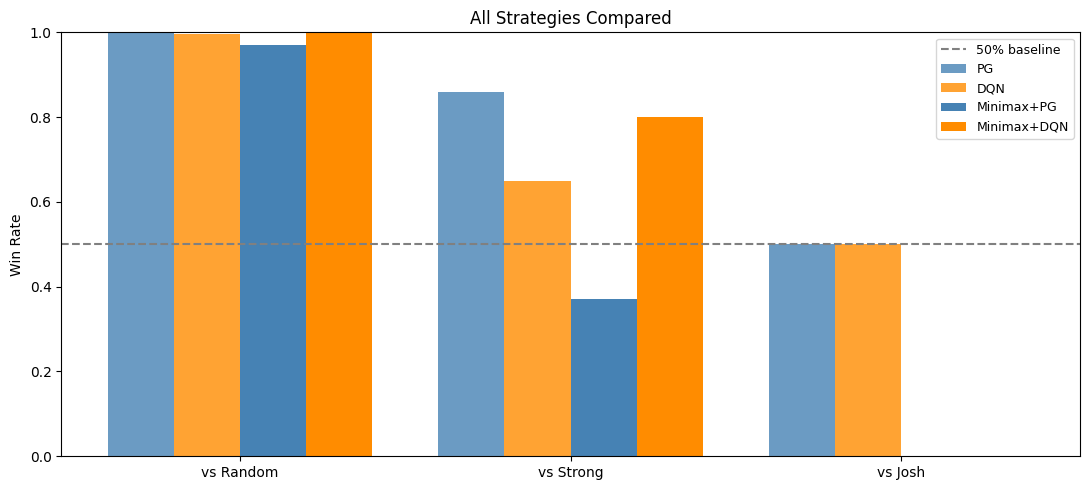

In [ ]:
# ── Full Summary Chart ───────────────────────────────────────────────────────
categories = ["vs Random", "vs Strong", "vs Josh"]
plain_pg  = [results["PG vs Random"]["win_rate"],
             results["PG vs Strong"]["win_rate"],
             results["PG vs Josh"]["win_rate"]]
plain_dqn = [results["DQN vs Random"]["win_rate"],
             results["DQN vs Strong"]["win_rate"],
             results["DQN vs Josh"]["win_rate"]]
mm_pg     = [mm_results["MM-PG vs Random"]["win_rate"],
             mm_results["MM-PG vs Strong"]["win_rate"],
             mm_results["MM-PG vs Josh"]["win_rate"]]
mm_dqn    = [mm_results["MM-DQN vs Random"]["win_rate"],
             mm_results["MM-DQN vs Strong"]["win_rate"],
             mm_results["MM-DQN vs Josh"]["win_rate"]]

x = np.arange(len(categories))
w = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 1.5*w, plain_pg,  w, label="PG",          color="steelblue",   alpha=0.8)
ax.bar(x - 0.5*w, plain_dqn, w, label="DQN",         color="darkorange",  alpha=0.8)
ax.bar(x + 0.5*w, mm_pg,     w, label="Minimax+PG",  color="steelblue",   alpha=1.0)
ax.bar(x + 1.5*w, mm_dqn,    w, label="Minimax+DQN", color="darkorange",  alpha=1.0)
ax.axhline(0.5, color="gray", linestyle="--", label="50% baseline")
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("All Strategies Compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("full_comparison.png", dpi=150)
plt.show()

## Final Tournament Selection Metric

To fairly select the strongest reinforcement learning agent, we combine two evaluation perspectives:

### 1. Baseline Performance
Each agent is tested against fixed benchmark opponents:
- Random agent (lower bound)
- Strong rule-based agent (classical heuristic baseline)
- Pretrained CNN agent (Josh)

This measures **absolute performance strength**.

### 2. Peer Performance
Each agent is also tested against other learned RL agents:
- PG (Policy Gradient)
- DQN (Deep Q-Network)
- Minimax-enhanced DQN (MM-DQN)

This measures **competitive strength against similar policies**.

### 3. Combined Score
We compute a weighted final score:

- 60% baseline performance (robustness vs known benchmarks)
  - Random agent: 10% weight (lower bound sanity check)
  - StrongRuleAgent: 60% weight (primary benchmark)
  - Josh CNN: 30% weight (MCTS-level opponent)
- 40% peer performance (competitive strength against similar policies)

This ensures the selected model is both:
- Strong against standard baselines
- Competitive against other RL approaches

The agent with the highest final score is selected as the tournament model.

In [7]:
# ── Final Tournament Selection ─────────────────────────────────────────────
baseline_opponents = [random_agent, strong_agent, josh_agent]

peer_opponents = {
    "PG":     pg_agent,
    "DQN":    dqn_agent,
    "MM-DQN": mm_dqn_agent,
}

baseline_scores = {}
for name, agent in peer_opponents.items():
    r_random = evaluate_agents(agent, random_agent, n_games=100)['win_rate']
    r_strong = evaluate_agents(agent, strong_agent, n_games=100)['win_rate']
    r_josh   = evaluate_agents(agent, josh_agent,   n_games=100)['win_rate']
    # weight: random 10%, strong 60%, josh 30%
    baseline_scores[name] = 0.1*r_random + 0.6*r_strong + 0.3*r_josh
    print(f"{name} baseline -- Random:{r_random:.0%} Strong:{r_strong:.0%} Josh:{r_josh:.0%} Weighted:{baseline_scores[name]:.3f}")

print()

peer_scores = {}
for name, agent in peer_opponents.items():
    wins = []
    for opp_name, opp_agent in peer_opponents.items():
        if opp_name == name:
            continue
        r = evaluate_agents(agent, opp_agent, n_games=50)
        wins.append(r["win_rate"])
        print(f"  {name} vs {opp_name}: {r['win_rate']:.0%}")
    peer_scores[name] = sum(wins) / len(wins)
    print(f"{name} peer score: {peer_scores[name]:.3f}\n")

final_scores = {}
for name in peer_opponents:
    final_scores[name] = 0.6 * baseline_scores[name] + 0.4 * peer_scores[name]

print(f"\n{'Agent':<12} {'Baseline':>10} {'Peer':>8} {'Final':>8}")
print("-" * 42)
for name in peer_opponents:
    print(f"{name:<12} {baseline_scores[name]:>10.3f} {peer_scores[name]:>8.3f} {final_scores[name]:>8.3f}")

winner = max(final_scores, key=final_scores.get)
print(f"\nSelected tournament agent: {winner}")
print(f"Final score: {final_scores[winner]:.3f}")
print("For tournament play: epsilon=0, strong=True, argmax move selection.")

PG baseline -- Random:100% Strong:89% Josh:50% Weighted:0.784
DQN baseline -- Random:99% Strong:65% Josh:50% Weighted:0.639
MM-DQN baseline -- Random:100% Strong:82% Josh:0% Weighted:0.592

  PG vs DQN: 0%
  PG vs MM-DQN: 100%
PG peer score: 0.500

  DQN vs PG: 100%
  DQN vs MM-DQN: 50%
DQN peer score: 0.750

  MM-DQN vs PG: 0%
  MM-DQN vs DQN: 50%
MM-DQN peer score: 0.250


Agent          Baseline     Peer    Final
------------------------------------------
PG                0.784    0.500    0.670
DQN               0.639    0.750    0.683
MM-DQN            0.592    0.250    0.455

Selected tournament agent: DQN
Final score: 0.683
For tournament play: epsilon=0, strong=True, argmax move selection.


## Qualitative Game Visualization

To complement the quantitative results, we visualize a few sample games between top agents (DQN, PG, and Minimax-enhanced DQN).

We run matches with both agents going first to account for first-move advantage. This allows us to verify that observed performance differences are reflected in actual gameplay.

In [12]:
def pretty_board(board):
    symbols = {0: ".", 1: "X", -1: "O"}
    for row in board:
        print(" ".join(symbols[x] for x in row))
    print("0 1 2 3 4 5 6\n")

def play_game(agent1, agent2, name1="Agent1", name2="Agent2", delay=0.5):
    import time

    board = make_board()
    player = 1  # agent1 starts
    done = False

    print(f"{name1} (1) vs {name2} (-1)\n")
    pretty_board(board)
    print("\n" + "-"*30)

    while not done:
        if player == 1:
            move = agent1.select_move(board, player)
            name = name1
        else:
            move = agent2.select_move(board, player)
            name = name2

        board, _ = step(board, move, player)

        print(f"\n{name} plays column {move}")
        pretty_board(board)
        print("-"*30)

        done, winner = game_over(board)
        player *= -1

        time.sleep(delay)  # slow it down so you can watch

    # final result
    if winner == 1:
        print(f"\n{name1} wins!")
    elif winner == -1:
        print(f"\n{name2} wins!")
    else:
        print("\nDraw!")

In [16]:
play_game(dqn_agent, mm_dqn_agent, "DQN", "MM-DQN")

DQN (1) vs MM-DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O X . .
. . . X O 

In [17]:
play_game(mm_dqn_agent, dqn_agent, "MM-DQN", "DQN")

MM-DQN (1) vs DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . 

In [20]:
play_game(dqn_agent, pg_agent, "DQN", "PG")

DQN (1) vs PG (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . . .
. . O X . . 

In [21]:
play_game(pg_agent, dqn_agent, "PG", "DQN")

PG (1) vs DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . X X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . . .
. . X X . . .
. . O X . . 

In [22]:
play_game(pg_agent, mm_dqn_agent, "PG", "MM-DQN")

PG (1) vs MM-DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

PG plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O X . .
. . . X O . .


In [23]:
play_game(mm_dqn_agent, pg_agent, "MM-DQN", "PG")

MM-DQN (1) vs PG (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . . .


### Results Summary

- **DQN** beats **MM-DQN** when it goes first, and vice versa when **MM-DQN** goes first.
- **DQN** beats **PG** whether it goes first or second.
- **PG** beats **MM-DQN** whether it goes first or second.

These results align with earlier evaluations, confirming that **DQN** performs consistently well and wins the final metric. For tournament play, **DQN** will be used, specifically the model file `dqn_best_cont.keras`, which showed the best performance in our final evaluation.